# 🔁 Repeat Purchase Decay Analysis — Multi-Window (30 / 60 / 90 / 180-Day)
**LushProtein Analytics | Medallion Architecture**

Analyses the **repeat purchase rate decay curve** across four time windows using `repeat_purchase_30d / 60d / 90d / 180d` flags added to `gold_customer_profiles`.

| Window | Business Interpretation |
|---|---|
| 30-day | Fastest re-order signal — products consumed quickly, or impulse re-buy |
| 60-day | Core repurchase cycle for a typical 2–2.5kg protein tub |
| 90-day | Current baseline used in all gold tables |
| 180-day | Longer-term loyalty signal — captures slow-burn repeat buyers |

> **What this answers:** When do first-time customers decide to return — and does this differ by channel, country, discount history, or product category?


## 0. Setup & Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

BASE_DIR   = Path('.')
GOLD_DIR   = BASE_DIR / 'medallion' / 'gold'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

WINDOWS       = [30, 60, 90, 180]
WINDOW_LABELS = ['30d', '60d', '90d', '180d']
WINDOW_COLS   = [f'repeat_purchase_{w}d' for w in WINDOWS]

COLORS = {
    'primary'  : '#2E86AB',
    'secondary': '#E84855',
    'accent'   : '#3BB273',
    'neutral'  : '#A8A8A8',
    'orange'   : '#F97316',
    'purple'   : '#7B2D8B',
}
PALETTE_4 = [COLORS['primary'], COLORS['accent'], COLORS['orange'], COLORS['secondary']]

sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete.')

Setup complete.


---
## 1. Load Data & Verify Multi-Window Flags

In [2]:
cf  = pd.read_parquet(GOLD_DIR / 'gold_churn_features.parquet')
fop = pd.read_parquet(GOLD_DIR / 'gold_first_order_products.parquet')

# Verify flags exist
for col in WINDOW_COLS:
    assert col in cf.columns, f'Missing column: {col}'

print(f'gold_churn_features: {len(cf):,} customers × {cf.shape[1]} cols')
print(f'\nRepeat purchase window counts:')
for col, lbl in zip(WINDOW_COLS, WINDOW_LABELS):
    n = cf[col].sum()
    print(f'  {lbl:6s}: {n:>5,}  ({n/len(cf):.1%})')

# Marginal gain per window
print(f'\nMarginal gain (new repeaters added per window):')
prev = 0
for col, lbl in zip(WINDOW_COLS, WINDOW_LABELS):
    n = cf[col].sum()
    print(f'  {lbl:6s}: +{n - prev:>4,}  ({(n - prev)/len(cf):.1%} of total customers)')
    prev = n

# Top product category from first order
top_cat = (fop[~fop['is_free_gift']]
           .groupby('customer_id')['product_category']
           .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
           .reset_index()
           .rename(columns={'product_category': 'top_category'}))
cf = cf.merge(top_cat, on='customer_id', how='left')

gold_churn_features: 12,819 customers × 47 cols

Repeat purchase window counts:
  30d   : 1,806  (14.1%)
  60d   : 2,456  (19.2%)
  90d   : 2,904  (22.7%)
  180d  : 3,465  (27.0%)

Marginal gain (new repeaters added per window):
  30d   : +1,806  (14.1% of total customers)
  60d   : + 650  (5.1% of total customers)
  90d   : + 448  (3.5% of total customers)
  180d  : + 561  (4.4% of total customers)


---
## 2. Overall Decay — Repeat Rate at Each Window

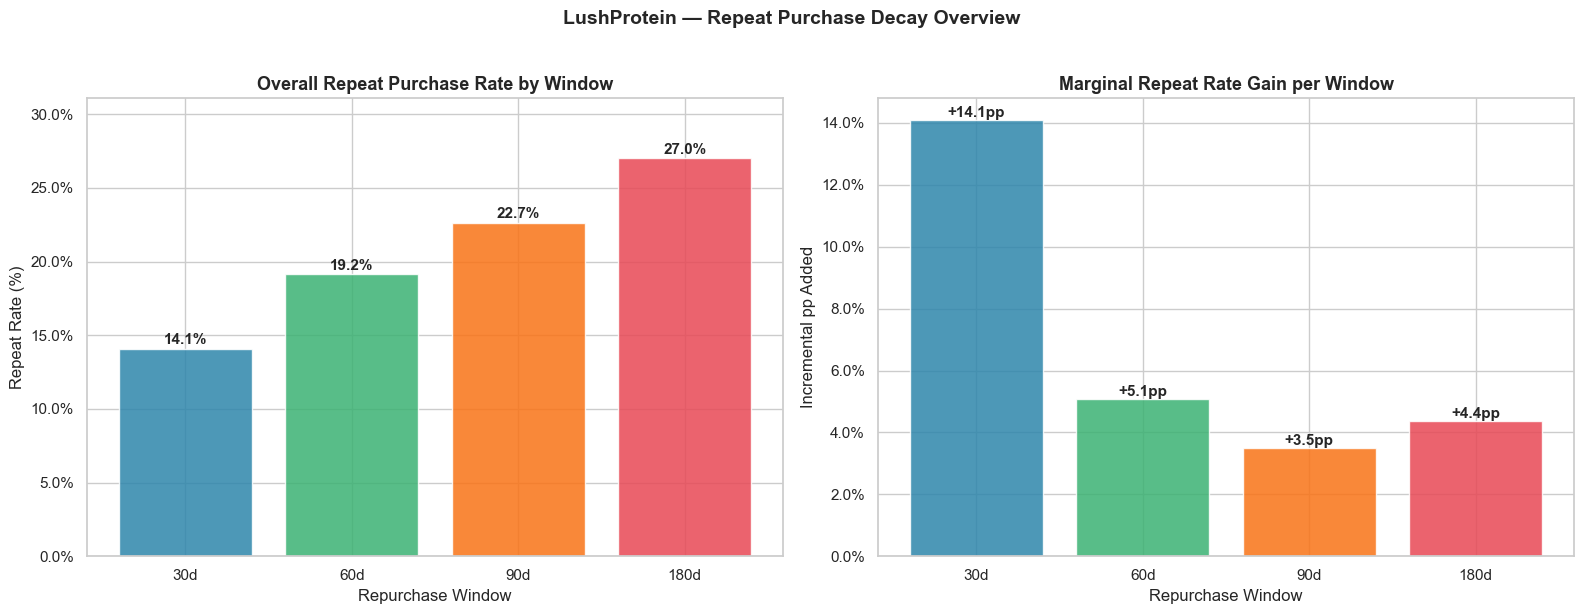

In [3]:
rates = [cf[col].mean() * 100 for col in WINDOW_COLS]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Repeat rates
ax1 = axes[0]
bars = ax1.bar(WINDOW_LABELS, rates, color=PALETTE_4, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Overall Repeat Purchase Rate by Window', fontsize=13, fontweight='bold')
ax1.set_xlabel('Repurchase Window')
ax1.set_ylabel('Repeat Rate (%)')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylim(0, max(rates) * 1.15)

# Panel 2: Marginal gain per window
ax2 = axes[1]
marginals = [rates[0]] + [rates[i] - rates[i-1] for i in range(1, len(rates))]
bars2 = ax2.bar(WINDOW_LABELS, marginals, color=PALETTE_4, alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, marginals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f'+{val:.1f}pp', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Marginal Repeat Rate Gain per Window', fontsize=13, fontweight='bold')
ax2.set_xlabel('Repurchase Window')
ax2.set_ylabel('Incremental pp Added')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('LushProtein — Repeat Purchase Decay Overview',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'repeat_decay_overall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Decay by Acquisition Channel

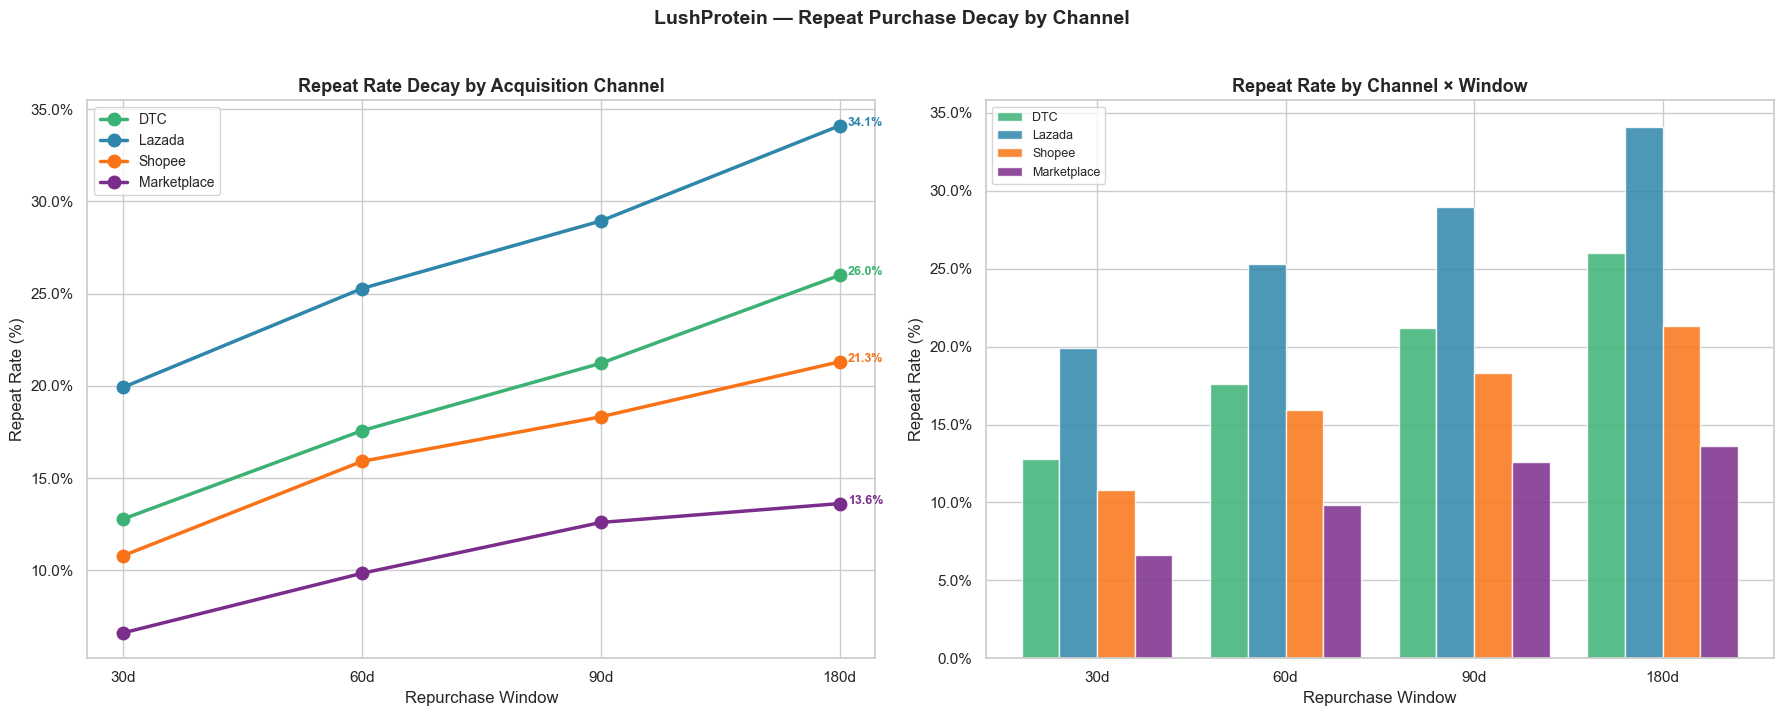


Repeat rates by channel:


,30d,60d,90d,180d
acquisition_channel,,,,
DTC,12.8%,17.6%,21.2%,26.0%
Lazada,19.9%,25.3%,28.9%,34.1%
Shopee,10.8%,15.9%,18.3%,21.3%
Marketplace,6.6%,9.8%,12.6%,13.6%


In [4]:
channel_order = ['DTC', 'Lazada', 'Shopee', 'Marketplace', 'Bulk Import',
                  'Subscription', 'POS', 'Draft Order']
ch_colors = {
    'DTC'         : '#3BB273',
    'Lazada'      : '#2E86AB',
    'Shopee'      : '#F97316',
    'Marketplace' : '#7B2D8B',
    'Bulk Import' : '#A8A8A8',
    'Subscription': '#E84855',
    'POS'         : '#F0C040',
    'Draft Order' : '#888888',
}

# Focus on the 4 main channels
main_channels = ['DTC', 'Lazada', 'Shopee', 'Marketplace']
cf_main = cf[cf['acquisition_channel'].isin(main_channels)].copy()

# Compute rates per channel per window
ch_rates = (cf_main.groupby('acquisition_channel')[WINDOW_COLS]
            .mean() * 100)
ch_rates.columns = WINDOW_LABELS
ch_rates = ch_rates.reindex([c for c in main_channels if c in ch_rates.index])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: Multi-line decay by channel
ax1 = axes[0]
for channel in ch_rates.index:
    color = ch_colors.get(channel, '#A8A8A8')
    ax1.plot(WINDOW_LABELS, ch_rates.loc[channel], marker='o', linewidth=2.5,
             markersize=9, label=channel, color=color)
    ax1.annotate(f'{ch_rates.loc[channel, "180d"]:.1f}%',
                 xy=(3, ch_rates.loc[channel, '180d']),
                 xytext=(6, 0), textcoords='offset points',
                 fontsize=9, color=color, fontweight='bold')
ax1.set_title('Repeat Rate Decay by Acquisition Channel', fontsize=13, fontweight='bold')
ax1.set_xlabel('Repurchase Window')
ax1.set_ylabel('Repeat Rate (%)')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(fontsize=10)

# Panel 2: Grouped bar at each window
ax2 = axes[1]
x = np.arange(len(WINDOW_LABELS))
width = 0.2
for i, channel in enumerate(ch_rates.index):
    offset = (i - len(ch_rates.index) / 2 + 0.5) * width
    bars = ax2.bar(x + offset, ch_rates.loc[channel], width,
                   label=channel, color=ch_colors.get(channel, '#A8A8A8'),
                   alpha=0.85, edgecolor='white')
ax2.set_title('Repeat Rate by Channel × Window', fontsize=13, fontweight='bold')
ax2.set_xlabel('Repurchase Window')
ax2.set_ylabel('Repeat Rate (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(WINDOW_LABELS)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=9)

plt.suptitle('LushProtein — Repeat Purchase Decay by Channel',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'repeat_decay_channel.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRepeat rates by channel:')
display(ch_rates.round(1).astype(str).add('%'))

---
## 4. Decay by Country (SG vs MY)

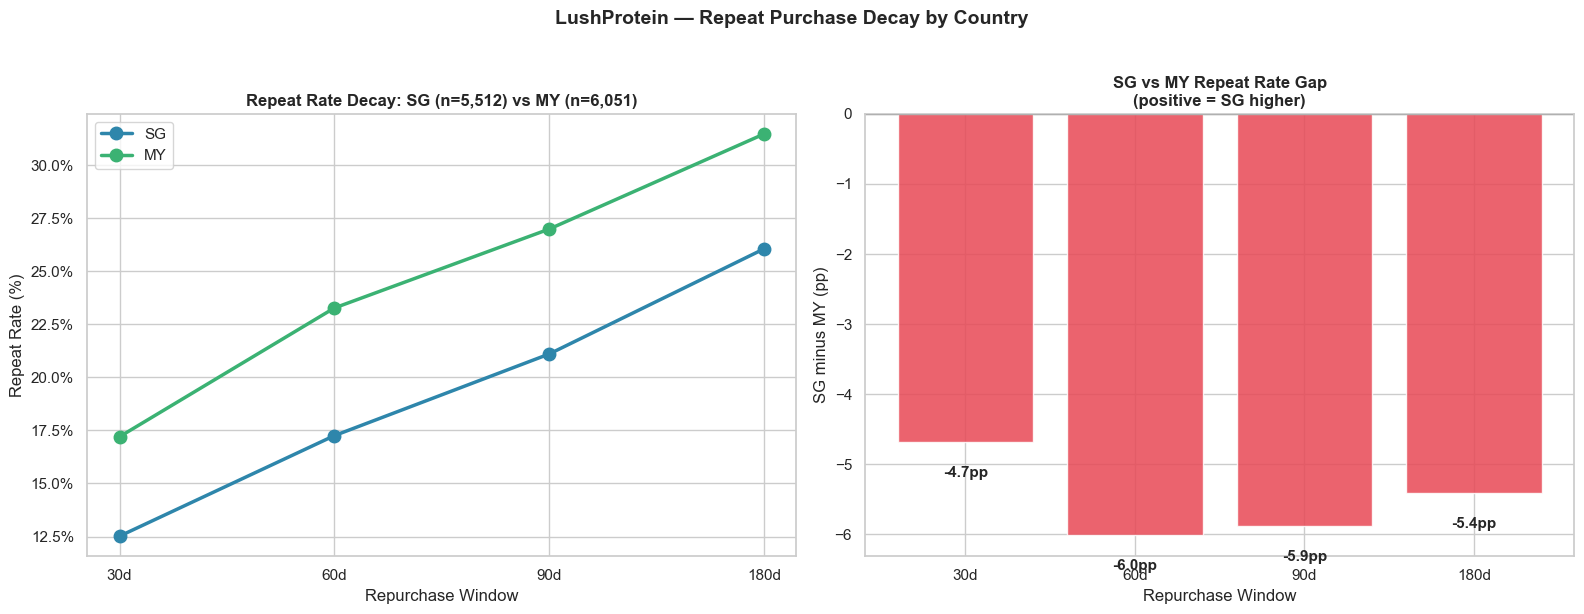


Repeat rates by country:


,30d,60d,90d,180d
country,,,,
MY,17.2%,23.3%,27.0%,31.5%
SG,12.5%,17.3%,21.1%,26.1%


In [5]:
def map_country(c):
    if pd.isna(c): return 'Other'
    c = str(c).upper().strip()
    if c in ('SG', 'SGP'): return 'SG'
    if c in ('MY', 'MYS'): return 'MY'
    return 'Other'

cf['country'] = cf['acquisition_country'].apply(map_country)
ctry_colors   = {'SG': '#2E86AB', 'MY': '#3BB273', 'Other': '#A8A8A8'}

ctry_rates = (cf[cf['country'].isin(['SG', 'MY'])]
              .groupby('country')[WINDOW_COLS]
              .mean() * 100)
ctry_rates.columns = WINDOW_LABELS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Line decay
ax1 = axes[0]
for ctry in ['SG', 'MY']:
    ax1.plot(WINDOW_LABELS, ctry_rates.loc[ctry], marker='o', linewidth=2.5,
             markersize=9, label=ctry, color=ctry_colors[ctry])
n_sg = (cf['country'] == 'SG').sum()
n_my = (cf['country'] == 'MY').sum()
ax1.set_title(f'Repeat Rate Decay: SG (n={n_sg:,}) vs MY (n={n_my:,})',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Repurchase Window')
ax1.set_ylabel('Repeat Rate (%)')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(fontsize=11)

# Panel 2: Gap chart — SG minus MY at each window
ax2 = axes[1]
gaps = ctry_rates.loc['SG'] - ctry_rates.loc['MY']
bar_colors = [COLORS['primary'] if g > 0 else COLORS['secondary'] for g in gaps]
bars = ax2.bar(WINDOW_LABELS, gaps, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + (0.1 if val >= 0 else -0.5),
             f'{val:+.1f}pp', ha='center', fontsize=11, fontweight='bold')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('SG vs MY Repeat Rate Gap\n(positive = SG higher)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Repurchase Window')
ax2.set_ylabel('SG minus MY (pp)')

plt.suptitle('LushProtein — Repeat Purchase Decay by Country',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'repeat_decay_country.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRepeat rates by country:')
display(ctry_rates.round(1).astype(str).add('%'))

---
## 5. Decay by Discount Acquisition

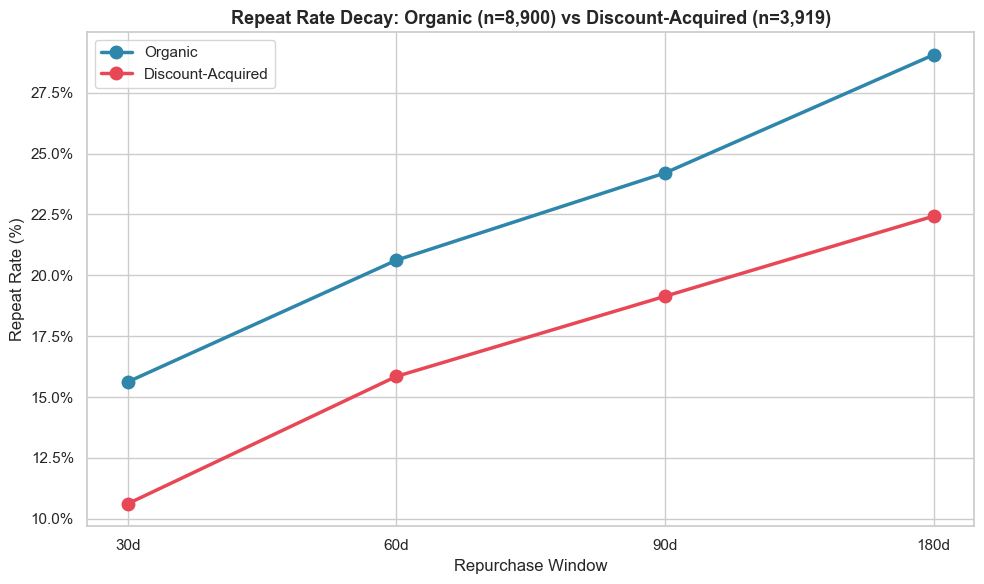


Repeat rates by discount acquisition:


,30d,60d,90d,180d
Organic,15.6%,20.6%,24.2%,29.1%
Discount-Acquired,10.6%,15.8%,19.1%,22.4%



Gap (Organic minus Discount-Acquired):
  30d: +5.0pp
  60d: +4.8pp
  90d: +5.1pp
  180d: +6.6pp


In [6]:
disc_rates = (cf.groupby('is_discount_acquired')[WINDOW_COLS]
              .mean() * 100)
disc_rates.columns = WINDOW_LABELS
disc_rates.index   = ['Organic', 'Discount-Acquired']

fig, ax = plt.subplots(figsize=(10, 6))
for label, color in [('Organic', COLORS['primary']),
                      ('Discount-Acquired', COLORS['secondary'])]:
    ax.plot(WINDOW_LABELS, disc_rates.loc[label], marker='o', linewidth=2.5,
            markersize=9, label=label, color=color)

n_org  = (~cf['is_discount_acquired']).sum()
n_disc = cf['is_discount_acquired'].sum()
ax.set_title(f'Repeat Rate Decay: Organic (n={n_org:,}) vs Discount-Acquired (n={n_disc:,})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Repurchase Window')
ax.set_ylabel('Repeat Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'repeat_decay_discount.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRepeat rates by discount acquisition:')
display(disc_rates.round(1).astype(str).add('%'))

# Gap analysis
print('\nGap (Organic minus Discount-Acquired):')
gap = disc_rates.loc['Organic'] - disc_rates.loc['Discount-Acquired']
for lbl, g in gap.items():
    print(f'  {lbl}: {g:+.1f}pp')

---
## 6. Decay by Top Product Category (First Order)

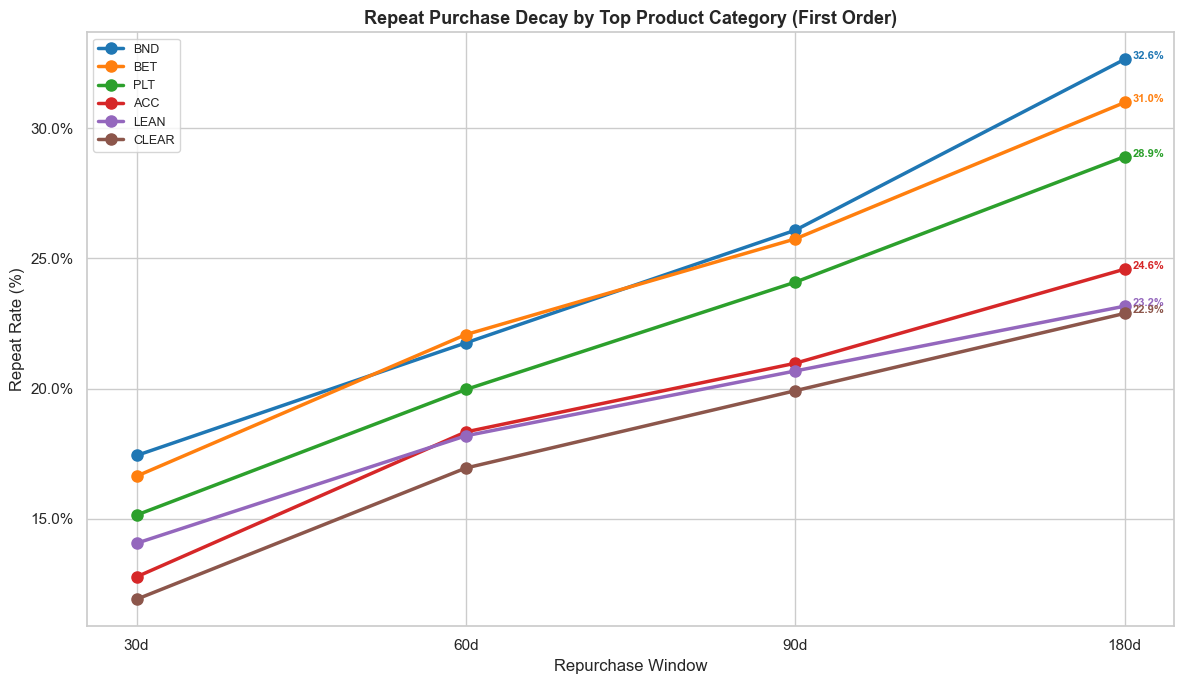


Repeat rates by top product category:


,30d,60d,90d,180d
top_category,,,,
BND,17.4%,21.8%,26.1%,32.6%
BET,16.6%,22.1%,25.7%,31.0%
PLT,15.2%,20.0%,24.1%,28.9%
ACC,12.8%,18.3%,21.0%,24.6%
LEAN,14.1%,18.2%,20.7%,23.2%
CLEAR,11.9%,17.0%,19.9%,22.9%


In [7]:
# Top 6 categories with enough customers
cat_counts = cf['top_category'].value_counts()
top_cats   = cat_counts[cat_counts >= 100].head(6).index.tolist()

cf_cats = cf[cf['top_category'].isin(top_cats)].copy()
cat_rates = (cf_cats.groupby('top_category')[WINDOW_COLS]
             .mean() * 100)
cat_rates.columns = WINDOW_LABELS
# Sort by 90d rate desc
cat_rates = cat_rates.sort_values('90d', ascending=False)

cat_palette = sns.color_palette('tab10', len(cat_rates))

fig, ax = plt.subplots(figsize=(12, 7))
for i, (cat, row) in enumerate(cat_rates.iterrows()):
    ax.plot(WINDOW_LABELS, row.values, marker='o', linewidth=2.5,
            markersize=8, label=cat, color=cat_palette[i])
    ax.annotate(f'{row["180d"]:.1f}%',
                xy=(3, row['180d']), xytext=(6, 0),
                textcoords='offset points', fontsize=8,
                color=cat_palette[i], fontweight='bold')

ax.set_title('Repeat Purchase Decay by Top Product Category (First Order)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Repurchase Window')
ax.set_ylabel('Repeat Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'repeat_decay_category.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRepeat rates by top product category:')
display(cat_rates.round(1).astype(str).add('%'))

---
## 7. Cross-Segment Heatmap

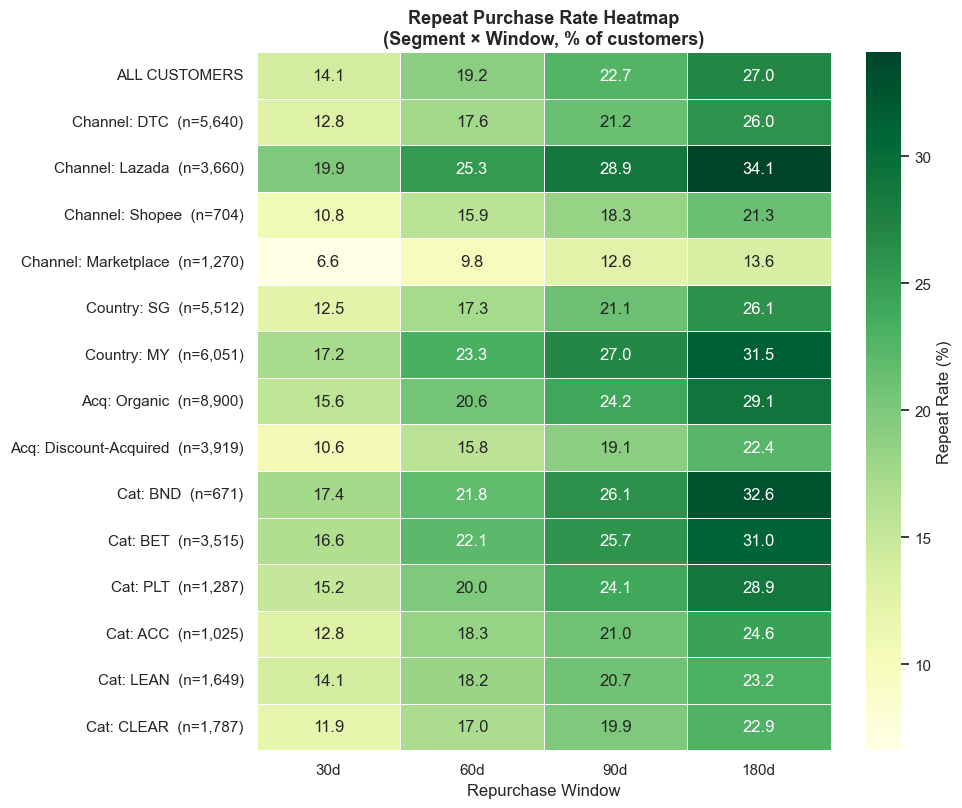

In [8]:
# Build a combined heatmap: segment × window
heatmap_rows = []

# Overall
heatmap_rows.append({'Segment': 'ALL CUSTOMERS', **{
    lbl: cf[col].mean() * 100 for col, lbl in zip(WINDOW_COLS, WINDOW_LABELS)}})

# By channel (main 4)
for ch in main_channels:
    sub = cf[cf['acquisition_channel'] == ch]
    if len(sub) < 50: continue
    heatmap_rows.append({'Segment': f'Channel: {ch}  (n={len(sub):,})', **{
        lbl: sub[col].mean() * 100 for col, lbl in zip(WINDOW_COLS, WINDOW_LABELS)}})

# By country
for ctry in ['SG', 'MY']:
    sub = cf[cf['country'] == ctry]
    heatmap_rows.append({'Segment': f'Country: {ctry}  (n={len(sub):,})', **{
        lbl: sub[col].mean() * 100 for col, lbl in zip(WINDOW_COLS, WINDOW_LABELS)}})

# By discount
for disc, label in [(False, 'Organic'), (True, 'Discount-Acquired')]:
    sub = cf[cf['is_discount_acquired'] == disc]
    heatmap_rows.append({'Segment': f'Acq: {label}  (n={len(sub):,})', **{
        lbl: sub[col].mean() * 100 for col, lbl in zip(WINDOW_COLS, WINDOW_LABELS)}})

# By top product category
for cat in cat_rates.index:
    sub = cf[cf['top_category'] == cat]
    heatmap_rows.append({'Segment': f'Cat: {cat}  (n={len(sub):,})', **{
        lbl: sub[col].mean() * 100 for col, lbl in zip(WINDOW_COLS, WINDOW_LABELS)}})

heatmap_df = pd.DataFrame(heatmap_rows).set_index('Segment')

fig, ax = plt.subplots(figsize=(10, max(6, len(heatmap_df) * 0.55)))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.1f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Repeat Rate (%)'},
    ax=ax
)
ax.set_title('Repeat Purchase Rate Heatmap\n(Segment × Window, % of customers)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Repurchase Window')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'repeat_decay_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Key Findings

In [9]:
print('=' * 65)
print('REPEAT PURCHASE DECAY — KEY FINDINGS')
print('=' * 65)

# Overall rates
rates_all = [cf[col].mean() * 100 for col in WINDOW_COLS]
print(f'\n1. OVERALL REPEAT RATES')
for lbl, r in zip(WINDOW_LABELS, rates_all):
    print(f'   {lbl:6s}: {r:.1f}%')

# Speed of repurchase
r30, r180 = rates_all[0], rates_all[3]
pct_captured_early = r30 / r180 * 100
print(f'\n   → {pct_captured_early:.0f}% of 180-day repeat customers are '
      f'captured within the first 30 days')

# Best and worst channels at 90d
print(f'\n2. CHANNEL COMPARISON (90-day rate)')
ch_90 = (cf[cf['acquisition_channel'].isin(main_channels)]
         .groupby('acquisition_channel')['repeat_purchase_90d']
         .mean() * 100).sort_values(ascending=False)
for ch, r in ch_90.items():
    print(f'   {ch:20s}: {r:.1f}%')

# SG vs MY at each window
print(f'\n3. SG vs MY COMPARISON')
for col, lbl in zip(WINDOW_COLS, WINDOW_LABELS):
    sg_r = cf[cf['country'] == 'SG'][col].mean() * 100
    my_r = cf[cf['country'] == 'MY'][col].mean() * 100
    gap  = sg_r - my_r
    print(f'   {lbl:6s}: SG={sg_r:.1f}%  MY={my_r:.1f}%  gap={gap:+.1f}pp')

# Organic vs discount
print(f'\n4. ORGANIC vs DISCOUNT-ACQUIRED (90-day)')
r_org  = cf[~cf['is_discount_acquired']]['repeat_purchase_90d'].mean() * 100
r_disc = cf[cf['is_discount_acquired']]['repeat_purchase_90d'].mean() * 100
print(f'   Organic          : {r_org:.1f}%')
print(f'   Discount-Acquired: {r_disc:.1f}%')
print(f'   Gap              : {r_org - r_disc:+.1f}pp')

REPEAT PURCHASE DECAY — KEY FINDINGS

1. OVERALL REPEAT RATES
   30d   : 14.1%
   60d   : 19.2%
   90d   : 22.7%
   180d  : 27.0%

   → 52% of 180-day repeat customers are captured within the first 30 days

2. CHANNEL COMPARISON (90-day rate)
   Lazada              : 28.9%
   DTC                 : 21.2%
   Shopee              : 18.3%
   Marketplace         : 12.6%

3. SG vs MY COMPARISON
   30d   : SG=12.5%  MY=17.2%  gap=-4.7pp
   60d   : SG=17.3%  MY=23.3%  gap=-6.0pp
   90d   : SG=21.1%  MY=27.0%  gap=-5.9pp
   180d  : SG=26.1%  MY=31.5%  gap=-5.4pp

4. ORGANIC vs DISCOUNT-ACQUIRED (90-day)
   Organic          : 24.2%
   Discount-Acquired: 19.1%
   Gap              : +5.1pp
